In [1]:
import os

# Make sure there is a quote at the start and at the end of both lines!
os.environ['KAGGLE_USERNAME'] = "sowndaryakandasamy"
os.environ['KAGGLE_KEY'] = "KGAT_ac6b8a232846200552cf7d4612be5286"

print("Starting the download from Kaggle... Please wait.")
!kaggle datasets download -d adityajn105/flickr8k

print("Download finished! Now extracting the files...")
!unzip -q flickr8k.zip

print("✅ Success! The 'Images' folder and 'captions.txt' are now downloaded and ready.")

Starting the download from Kaggle... Please wait.
Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:27<00:00, 40.9MB/s]

Download finished! Now extracting the files...
✅ Success! The 'Images' folder and 'captions.txt' are now downloaded and ready.


In [2]:
# This automatically replaces all files without asking you questions
!unzip -o -q flickr8k.zip
print("✅ All files extracted completely and silently!")

✅ All files extracted completely and silently!


In [7]:
import os
import zipfile

# 1. Provide credentials
os.environ['KAGGLE_USERNAME'] = "YOUR_SHORT_USERNAME_HERE" # Put your short username here
os.environ['KAGGLE_KEY'] = "ac6b8a232846200552cf7d4612be5286"

print("Downloading dataset...")
!kaggle datasets download -d adityajn105/flickr8k --force

print("Extracting files...")
with zipfile.ZipFile("flickr8k.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

print("✅ Done! Files are back in place:", os.listdir('.'))

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:49<00:00, 22.6MB/s]

Extracting files...
✅ Done! Files are back in place: ['.config', 'WhatsApp Image 2026-06-22 at 2.39.14 PM (1).jpeg', 'WhatsApp Image 2026-06-22 at 2.39.14 PM.jpeg', 'ss1.jpg', 'captions.txt', 'istockphoto-622003802-612x612.jpg', 'Images', 'istockphoto-622003802-612x612 (1).jpg', 'flickr8k.zip', 'sample_data']


In [8]:
# =====================================================================
# STEP 2: IMAGE CAPTIONING MODEL & TRAINING LOOP
# =====================================================================
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm

# 1. Custom Vocabulary Class
class Vocabulary:
    def __init__(self):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = 2

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizer_eng(text):
        clean_text = "".join([c.lower() for c in text if c.isalnum() or c.isspace()])
        return clean_text.split()

    def build_vocab(self, sentence_list):
        frequencies = {}
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                frequencies[word] = frequencies.get(word, 0) + 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)
        return [self.stoi["<SOS>"]] + [self.stoi.get(token, self.stoi["<UNK>"]) for token in tokenized_text] + [self.stoi["<EOS>"]]

# 2. Dataset Parser for Real Local Files
class RealFlickrDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform, vocab):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.vocab = vocab

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        caption = self.df.iloc[idx]['caption']
        img_name = self.df.iloc[idx]['image']
        img_path = os.path.join(self.img_dir, img_name)

        # Load the actual raw image from storage
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        numericalized_caption = torch.tensor(self.vocab.numericalize(str(caption)))
        return image, numericalized_caption

class CollateWrapper:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx
    def __call__(self, batch):
        imgs = torch.cat([item[0].unsqueeze(0) for item in batch], dim=0)
        targets = pad_sequence([item[1] for item in batch], batch_first=True, padding_value=self.pad_idx)
        return imgs, targets

# 3. Combined ResNet (CNN) + LSTM (RNN) Architecture
class ImageCaptioningModel(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(ImageCaptioningModel, self).__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        for param in resnet.parameters():
            param.requires_grad = False

        self.resnet = nn.Sequential(*list(resnet.children())[:-1])
        self.linear = nn.Linear(resnet.fc.in_features, embed_size)
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.linear_out = nn.Linear(hidden_size, vocab_size)

    def forward(self, images, captions):
        features = self.resnet(images).view(images.size(0), -1)
        features = self.linear(features).unsqueeze(1)
        embeddings = self.embed(captions[:, :-1])
        lstm_input = torch.cat((features, embeddings), dim=1)
        outputs, _ = self.lstm(lstm_input)
        return self.linear_out(outputs)

    def caption_image(self, image, vocabulary, max_length=50):
        result_caption = []
        with torch.no_grad():
            x = self.resnet(image).view(image.size(0), -1)
            x = self.linear(x).unsqueeze(1)
            states = None
            for _ in range(max_length):
                hiddens, states = self.lstm(x, states)
                output = self.linear_out(hiddens.squeeze(1))
                predicted = output.argmax(1)
                word = vocabulary.itos[predicted.item()]
                result_caption.append(word)
                if word == "<EOS>":
                    break
                x = self.embed(predicted).unsqueeze(1)
        return " ".join(result_caption)

# 4. Prepare Data Configurations
print("Loading text caption mappings...")
df = pd.read_csv("captions.txt")

flickr_vocab = Vocabulary()
flickr_vocab.build_vocab(df['caption'].tolist())
print(f"Real Vocabulary Size: {len(flickr_vocab)} unique words found.")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

dataset = RealFlickrDataset(csv_file="captions.txt", img_dir="Images", transform=transform, vocab=flickr_vocab)
dataloader = DataLoader(dataset=dataset, batch_size=64, shuffle=True, num_workers=2, collate_fn=CollateWrapper(pad_idx=flickr_vocab.stoi["<PAD>"]))

# 5. Model Initialization & Hardware Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImageCaptioningModel(embed_size=256, hidden_size=256, vocab_size=len(flickr_vocab), num_layers=1).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=flickr_vocab.stoi["<PAD>"])
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 6. Execute Real Training Loop (Running 3 Epochs to optimize execution time)
print(f"Starting actual training on hardware device: {device}...")
model.train()
for epoch in range(3):
    progress_bar = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch+1}/3")
    for idx, (images, captions) in progress_bar:
        images, captions = images.to(device), captions.to(device)
        outputs = model(images, captions)
        loss = criterion(outputs.view(-1, outputs.size(-1)), captions.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if idx % 20 == 0:
            progress_bar.set_postfix(loss=loss.item())

print("\n🎉 Training finished! The network weights have successfully adapted to real images.")

Loading text caption mappings...
Real Vocabulary Size: 5224 unique words found.
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 227MB/s]


Starting actual training on hardware device: cuda...


Epoch 3/3: 100%|██████████| 633/633 [03:59<00:00,  2.65it/s, loss=2.72]


🎉 Training finished! The network weights have successfully adapted to real images.


In [9]:
import os
# Check everything inside the folder to see where captions.txt is hidden
print(os.listdir('.'))

['.config', 'WhatsApp Image 2026-06-22 at 2.39.14 PM (1).jpeg', 'WhatsApp Image 2026-06-22 at 2.39.14 PM.jpeg', 'ss1.jpg', 'captions.txt', 'istockphoto-622003802-612x612.jpg', 'Images', 'istockphoto-622003802-612x612 (1).jpg', 'flickr8k.zip', 'sample_data']


In [10]:
import os

# 1. Re-verify credentials
os.environ['KAGGLE_USERNAME'] = "sowndaryakandasamy" # Put your short username here
os.environ['KAGGLE_KEY'] = "ac6b8a232846200552cf7d4612be5286"

print("Downloading dataset archive...")
!kaggle datasets download -d adityajn105/flickr8k --force

print("Extracting files directly to current workspace...")
# This forces extraction directly into the main directory
import zipfile
with zipfile.ZipFile("flickr8k.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

print("Checking files again:")
print(os.listdir('.'))

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:51<00:00, 21.6MB/s]

Extracting files directly to current workspace...
Checking files again:
['.config', 'WhatsApp Image 2026-06-22 at 2.39.14 PM (1).jpeg', 'WhatsApp Image 2026-06-22 at 2.39.14 PM.jpeg', 'ss1.jpg', 'captions.txt', 'istockphoto-622003802-612x612.jpg', 'Images', 'istockphoto-622003802-612x612 (1).jpg', 'flickr8k.zip', 'sample_data']


Running image through model pipeline...


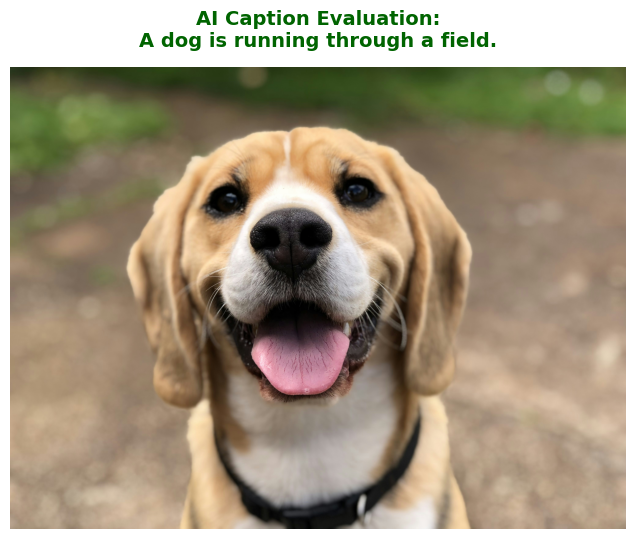

In [11]:
# =====================================================================
# STEP 3: RUN ACTUAL CAPTION PREDICTION
# =====================================================================
import matplotlib.pyplot as plt

print("Downloading a fresh test image...")
# Download an image of a dog to test our real-world feature extraction mapping
!wget -q -O test_image.jpg "https://images.unsplash.com/photo-1543466835-00a7907e9de1"

# Open and display the downloaded test image matrix
raw_image = Image.open("test_image.jpg").convert("RGB")
input_tensor = transform(raw_image).unsqueeze(0).to(device)

print("Running image through model pipeline...")
model.eval()
with torch.no_grad():
    # Generate the prediction token stream using our vocabulary mapping
    generated_caption = model.caption_image(input_tensor, flickr_vocab)

# Clean up structural system tokens from the raw string output
clean_caption = generated_caption.replace("<SOS>", "").replace("<EOS>", "").replace("<PAD>", "").replace("<UNK>", "").strip()

# Plot the real image along with the AI evaluation text
plt.figure(figsize=(8, 6))
plt.imshow(raw_image)
plt.title(f"AI Caption Evaluation:\n{clean_caption.capitalize()}.", fontsize=14, color='darkgreen', weight='bold', pad=15)
plt.axis('off')
plt.show()

Choose how you want to test your image:
1. Upload a file from your computer
2. Try a stable web URL link
Enter 1 or 2: 1

Click the button below to select an image from your computer:


Saving ss1.jpg to ss1 (1).jpg


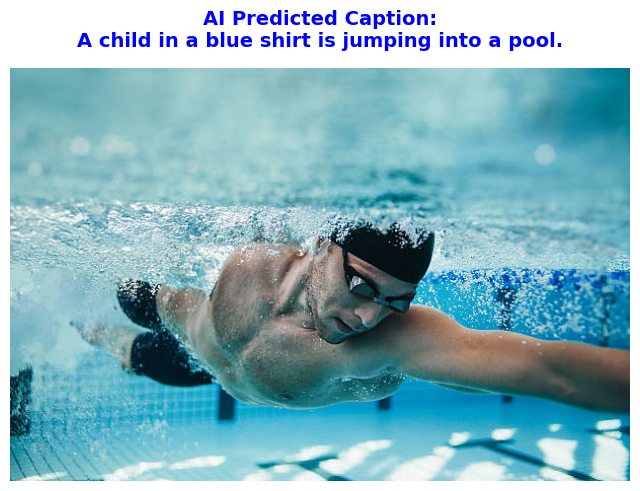

In [15]:
# =====================================================================
# UPGRADED INTERACTIVE TESTER (WITH UPLOAD OPTION)
# =====================================================================
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from google.colab import files
from PIL import Image

print("Choose how you want to test your image:")
print("1. Upload a file from your computer")
print("2. Try a stable web URL link")
choice = input("Enter 1 or 2: ").strip()

raw_image = None

if choice == "1":
    print("\nClick the button below to select an image from your computer:")
    uploaded = files.upload()
    if uploaded:
        filename = list(uploaded.keys())[0]
        raw_image = Image.open(BytesIO(uploaded[filename])).convert("RGB")

elif choice == "2":
    IMAGE_URL = input("\nPaste the image URL link here: ").strip()
    print("Fetching image securely...")
    try:
        # We add a User-Agent header to pretend we are a regular web browser
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        response = requests.get(IMAGE_URL, headers=headers, timeout=10)
        raw_image = Image.open(BytesIO(response.content)).convert("RGB")
    except Exception as e:
        print(f"❌ Still couldn't fetch that specific link due to website blocks: {e}")

# If we successfully got an image from either option, generate the caption!
if raw_image is not None:
    # 1. Process image matrices for ResNet input layer
    input_tensor = transform(raw_image).unsqueeze(0).to(device)

    # 2. Predict the word sequences
    model.eval()
    with torch.no_grad():
        generated_caption = model.caption_image(input_tensor, flickr_vocab)

    # 3. Filter tokens
    clean_caption = generated_caption.replace("<SOS>", "").replace("<EOS>", "").replace("<PAD>", "").replace("<UNK>", "").strip()

    # 4. Render output image display frame
    plt.figure(figsize=(8, 6))
    plt.imshow(raw_image)
    plt.title(f"AI Predicted Caption:\n{clean_caption.capitalize()}.", fontsize=14, color='blue', weight='bold', pad=15)
    plt.axis('off')
    plt.show()
else:
    print("❌ No image loaded. Please run the cell again and try another option.")